<a href="https://colab.research.google.com/github/kclu-bio/natural_product/blob/main/notebooks/match_origin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch.nn as nn
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import re
import pickle

CURRENT_DIR=os.getcwd()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
target_folder = '/content/drive/MyDrive/natural_product'
os.chdir(target_folder)
CURRENT_DIR=os.getcwd()
print(CURRENT_DIR)

/content/drive/MyDrive/natural_product


In [ ]:
!pip install rotary-embedding-torch

In [ ]:
from torch.nn import MultiheadAttention
from rotary_embedding_torch import RotaryEmbedding
import torch.nn.functional as F

class MultiheadAttentionWithROPE(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.3,batch_first=None):
        super(MultiheadAttentionWithROPE, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.dropout = nn.Dropout(dropout)
        # Ensure the embedding dimension can be split into the number of heads
        assert embed_dim % num_heads == 0
        self.head_dim = embed_dim // num_heads

        # Define linear layers for query, key, value projections
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        # Instantiate rotary embedding
        self.rotary_emb = RotaryEmbedding(dim=self.head_dim)

    def forward(self, query, key, value, key_padding_mask=None): #key_padding_mask must be binary
        batch_size, seq_len, embed_dim = query.size()

        # Linear projections for query, key, value
        q = self.q_proj(query).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(key).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(value).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        # Apply rotary embeddings to queries and keys
        q = self.rotary_emb.rotate_queries_or_keys(q)  # Apply ROPE to queries
        k = self.rotary_emb.rotate_queries_or_keys(k)  # Apply ROPE to keys

        # Scaled dot-product attention
        #q:(batch_size, num_heads, seq_len, head_dim)
        #k.transpose(-2,-1):(batch_size, num_heads, head_dim, seq_len)
        attn_weights = torch.matmul(q, k.transpose(-2, -1)) / (self.head_dim ** 0.5) #(bacth_size,num_heads,seq_len,seq_len)

        # Optional key_padding_mask (e.g., for padding or causal masking)
        if key_padding_mask is not None:
            # key_padding_mask shape: (batch_size, seq_len) -> need to expand for multi-head attention
            # We expand it to (batch_size, 1, 1, seq_len) and apply it across all heads and queries
            key_padding_mask = key_padding_mask.unsqueeze(1).unsqueeze(2)  # Shape: (batch_size, 1, 1, seq_len)
            attn_weights = attn_weights.masked_fill(key_padding_mask == True, float('-inf'))

        # Softmax over the attention weights
        attn_weights = F.softmax(attn_weights, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Compute attention output
        attn_output = torch.matmul(attn_weights, v)

        # Reshape and project back to the original embedding dimension
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, embed_dim)
        attn_output = self.out_proj(attn_output)

        return attn_output, attn_weights

In [ ]:
class BCEFocalLoss(torch.nn.Module):
    def __init__(self, gamma=2, alpha=0.7, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, _input, target):
        pt = torch.sigmoid(_input)
        #pt = _input
        alpha = self.alpha
        loss = - alpha * (1 - pt) ** self.gamma * target * torch.log(pt) - \
               (1 - alpha) * pt ** self.gamma * (1 - target) * torch.log(1 - pt)
        if self.reduction == 'mean':
            loss = torch.mean(loss)
        elif self.reduction == 'sum':
            loss = torch.sum(loss)
        return loss

##data_preprocess

In [ ]:
def generate_tvt(data,train_frac,val_frac,train_path,val_path,test_path,save_data=False): #divide the data into train set ,validation set and test set
    import random
    data=data.copy()
    data=data.sample(frac=1,random_state=random.randint(1, 100000)).reset_index(drop=True)
    train_size = int(train_frac * len(data))
    val_size = int(val_frac * len(data))
    test_size=len(data)-train_size-val_size

    train_data = data[:train_size]
    val_data = data[train_size:train_size+val_size]
    test_data=data[train_size+val_size:]
    if save_data:
      train_data.to_pickle(train_path)
      val_data.to_pickle(val_path)
      test_data.to_pickle(test_path)
      print("successfully saved",f"train_size:{train_size},val_size:{val_size},test_size:{test_size}")
    return train_data,val_data,test_data


In [ ]:
BGC_data=pd.read_pickle(os.path.join(CURRENT_DIR,"data","try1","try1_randomsample.pkl"))
train_path=os.path.join(CURRENT_DIR,"data","try1","try1_randomsample_train.pkl")
val_path=os.path.join(CURRENT_DIR,"data","try1","try1_randomsample_val.pkl")
test_path=os.path.join(CURRENT_DIR,"data","try1","try1_randomsample_test.pkl")
#generate_tvt(BGC_data,0.8,0.1,train_path,val_path,test_path)

## Model Construction

In [ ]:
smiles_dict={'#': 0, '%10': 1, '%11': 2, '%12': 3, '%13': 4, '%14': 5, '%15': 6, '(': 7, ')': 8, '.': 9, '1': 10, '2': 11, '3': 12, '4': 13, '5': 14, '6': 15, '7': 16, '8': 17, '9': 18, '=': 19, 'B': 20, 'Br': 21, 'C': 22, 'Cl': 23, 'F': 24, 'I': 25, 'N': 26, 'O': 27, 'P': 28, 'S': 29, '[*]': 30, '[55Fe+3]': 31, '[As+]': 32, '[As]': 33, '[B-]': 34, '[B@-]': 35, '[C+]': 36, '[C-]': 37, '[C@@H]': 38, '[C@@]': 39, '[C@H]': 40, '[C@]': 41, '[CH+]': 42, '[CH-]': 43, '[CH2-]': 44, '[CH]': 45, '[C]': 46, '[Fe+2]': 47, '[Fe+3]': 48, '[Fe+]': 49, '[Fe-3]': 50, '[FeH2-2]': 51, '[Fe]': 52, '[H+]': 53, '[H]': 54, '[IH2]': 55, '[Mo+2]': 56, '[N+]': 57, '[N-]': 58, '[N@+]': 59, '[N@@+]': 60, '[N@@H+]': 61, '[N@@]': 62, '[N@H+]': 63, '[N@]': 64, '[NH+]': 65, '[NH-]': 66, '[NH2+]': 67, '[NH3+]': 68, '[NH]': 69, '[N]': 70, '[Na+]': 71, '[Na]': 72, '[Ni]': 73, '[O-]': 74, '[OH+]': 75, '[OH2+]': 76, '[O]': 77, '[P+]': 78, '[P@@]': 79, '[P@H]': 80, '[P@]': 81, '[PH]': 82, '[P]': 83, '[S+]': 84, '[S-]': 85, '[S@+]': 86, '[S@@]': 87, '[S@]': 88, '[SH]': 89, '[SeH]': 90, '[Se]': 91, '[Si]': 92, '[c-]': 93, '[cH+]': 94, '[cH-]': 95, '[n+]': 96, '[n-]': 97, '[nH]': 98, 'c': 99, 'n': 100, 'o': 101, 's': 102}
SMI_REGEX_PATTERN = r"(\[[^\]]+\]|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|\+|\\\/|:|@|\?|\>|\*|\$|\%[0-9]{2}|[0-9])"
vocab_size=len(smiles_dict)
print(vocab_size)
def get_smiles_index(smiles,index_dict):
  split = re.findall(SMI_REGEX_PATTERN, smiles)
  tokens=[index_dict[x] for x in split]
  return torch.tensor(tokens)
example="CC1CC23OC(=O)C4=C2OC1C(O)C3\\C=C/C(=O)C(C)CC(C)C4=O"
print(get_smiles_index(example,smiles_dict))
structure_token = {
    'A': 0, 'C': 1, 'D': 2, 'E': 3, 'F': 4, 'G': 5, 'H': 6, 'I': 7,
    'K': 8, 'L': 9, 'M': 10, 'N': 11, 'P': 12, 'Q': 13, 'R': 14,
    'S': 15, 'T': 16, 'V': 17, 'W': 18, 'Y': 19, "X": 20, "#":21
}

103
tensor([22, 22, 10, 22, 22, 11, 12, 27, 22,  7, 19, 27,  8, 22, 13, 19, 22, 11,
        27, 22, 10, 22,  7, 27,  8, 22, 12, 22, 19, 22, 22,  7, 19, 27,  8, 22,
         7, 22,  8, 22, 22,  7, 22,  8, 22, 13, 19, 27])


In [ ]:
class FeedForward(nn.Module):
    def __init__(self, input_dim, hidden_dim , activation , dropout=0.3):
        super(FeedForward, self).__init__()
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.activation = activation
        self.dropout=nn.Dropout(dropout)
        self.linear2 = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return x

In [ ]:
class CrossAttentionClassifier(nn.Module):
    def __init__(self, embed_size=1280, attention_dim=512,heads=8,vocab_size=103,dropout=0.3,rope=(True,True),unimol=False):
        super(CrossAttentionClassifier, self).__init__()
        self.embedding=nn.Embedding(vocab_size+1,attention_dim,padding_idx=vocab_size) #[batch,seqlen]->[batch,seqlen,embed_size]
        self.projection=nn.Linear(embed_size,attention_dim)
        self.projection1=nn.Linear(attention_dim*2,attention_dim)
        self.activation=nn.GELU()
        self.feedforward1 = FeedForward(attention_dim, attention_dim*2, self.activation, dropout)
        self.feedforward2 = FeedForward(attention_dim, attention_dim*2, self.activation, dropout)
        self.feedforward3 = FeedForward(attention_dim, attention_dim*2, self.activation, dropout)
        self.feedforward4 = FeedForward(attention_dim, attention_dim*2, self.activation, dropout)
        self.projection2=nn.Linear(attention_dim,attention_dim)
        self.projection3=nn.Linear(attention_dim,attention_dim)

        self.unimol=unimol
        if unimol:
          self.alpha = nn.Parameter(torch.ones(1))
        else:
          self.alpha=torch.zeros(1, device='cuda' if torch.cuda.is_available() else 'cpu')
        if rope[0]:
          self.self_attention1 = MultiheadAttentionWithROPE(attention_dim, heads, dropout=dropout,batch_first=True) #[batch,seqlen,embed_size]->[batch,seqlen,embed_size]
        else:
          self.self_attention1 = MultiheadAttention(attention_dim, heads, dropout=dropout,batch_first=True) #[batch,seqlen,embed_size]->[batch,seqlen,embed_size]
        if rope[1]:
          self.self_attention2 = MultiheadAttentionWithROPE(attention_dim, heads, dropout=dropout,batch_first=True)
        else:
          self.self_attention2 = MultiheadAttention(attention_dim, heads, dropout=dropout,batch_first=True)
        self.cross_attention1 = nn.MultiheadAttention(attention_dim, heads, dropout=dropout,batch_first=True)
        #self.cross_attention2 = nn.MultiheadAttention(attention_dim, heads, dropout=dropout,batch_first=True)

        self.norm1 = nn.LayerNorm(attention_dim)
        self.norm2 = nn.LayerNorm(attention_dim)
        self.norm3 = nn.LayerNorm(attention_dim)
        self.norm4 = nn.LayerNorm(attention_dim)
        self.norm5 = nn.LayerNorm(attention_dim)
        self.norm6 = nn.LayerNorm(attention_dim)
        self.norm7 = nn.LayerNorm(attention_dim)
        self.norm8 = nn.LayerNorm(attention_dim)

        self.fc = nn.Linear(attention_dim, 1)  # 输出二分类结果
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()  # 使用 Sigmoid 进行二分类

    def forward(self, pros, subs, unimol_repr, mask1=None, mask2=None):
        # Self-Attention on pros
        subs_embedded=self.embedding(subs)
        pros=self.activation(self.projection(pros))
        self_attn_output1, _ = self.self_attention1(pros, pros, pros, key_padding_mask=mask1) #pros:[batch,seqlen,embed_size] #mask:[batch,seqlen]
        self_attn_output1 = self.norm1(self_attn_output1 + pros)
        #residue = self_attn_output1
        #self_attn_output1 = self.feedforward1(self_attn_output1)
        #self_attn_output1 = self.norm5(self_attn_output1+residue)

        if self.unimol:
          unimol_repr=unimol_repr.unsqueeze(1) #[batch,embed_size]->[batch,1,embed_size]
          alpha=self.alpha.view(1,1).expand(subs_embedded.size(0),subs_embedded.size(1)) #[1]->[batch,seq_len]
          subs_embedded=subs_embedded+(alpha.unsqueeze(-1)*unimol_repr)
          #[batch,seq_len,embed_dim]+[batch,seq_len,1]*[batch,1,embed_dim]

        # Self-Attention on seq2
        self_attn_output2, _ = self.self_attention2(subs_embedded, subs_embedded, subs_embedded, key_padding_mask=mask2)
        self_attn_output2 = self.norm2(self_attn_output2 + subs_embedded)
        #residue = self_attn_output2
        #self_attn_output2 = self.feedforward2(self_attn_output2)
        #self_attn_output2 = self.projection2(self_attn_output2)
        #self_attn_output2 = self.norm6(self_attn_output2+residue)

        # Cross-Attention: pros (Query) to subs (Key/Value)

        cross_attn_output1, _ = self.cross_attention1(self_attn_output1, self_attn_output2, self_attn_output2, key_padding_mask=mask2)
        cross_attn_output1 = self.norm3(cross_attn_output1 + self_attn_output1)
        #residue=cross_attn_output1
        #cross_attn_output1=self.feedforward3(cross_attn_output1)
        #cross_attn_output1=self.norm7(residue+cross_attn_output1)


        # Cross-Attention: subs (Query) to pros (Key/Value)

        #cross_attn_output2, _ = self.cross_attention1(self_attn_output2, self_attn_output1, self_attn_output1, key_padding_mask=mask1)
        #cross_attn_output2 = self.norm4(cross_attn_output2 + self_attn_output2)
        #residue=cross_attn_output2
        #cross_attn_output2=self.feedforward4(cross_attn_output2)
        #cross_attn_output2=self.norm8(residue+cross_attn_output2)


        # Global average pooling
        out1 = torch.mean(cross_attn_output1, dim=1)  # [batch_size, seq_len,attention_dim]->[bs,embed]
        #out2 = torch.mean(cross_attn_output2, dim=1)  # [batch_size, seq_len,attention_dim]->[bs,embed]

        # Concatenate and classify
        #out = torch.cat([out1, out2], dim=1)  # [batch_size, attention_dim * 2]
        out = self.activation(self.projection3(out1))
        #residue=out1
        #out = self.feedforward3(out1)
        #out = self.norm7(out+residue)
        out = self.dropout(out1)
        out = self.fc(out)  # [batch_size, 1]
        #out = self.sigmoid(out)  # Sigmoid activation for binary classification

        return out

## Load Data

In [ ]:
class AttentionDataset(object):
    def __init__(self, BGCs, biosyn_class,pros,subs,is_product,unimol_repr,gene_kind,pfam):
        self.BGCs = list(BGCs)
        self.length = [len(x) for x in pros] #enzyme/domain的总数
        self.biosyn_class=list(biosyn_class)
        self.pfam=list(pfam)
        self.gene_kind=list(gene_kind)
        self.unimol_repr=list(unimol_repr)
        self.pros=list(pros)
        self.subs = list(subs)
        self.is_product=list(is_product)

    @classmethod
    def from_df(cls, data):
        BGCs = data["BGC_number"].tolist()
        biosyn_class=data["biosyn_class"].tolist()
        biosyn_class=[tuple(x) for x in biosyn_class]
        pros = data["protein_rep"].tolist()
        subs = data["product_index"].tolist()
        is_product=data["is_product"].to_list()
        gene_kind=data["gene_kind"].to_list()
        unimol_repr=data["unimol_repr"].to_list()
        pfam=data["pfam"].to_list()
        return cls(BGCs,biosyn_class,pros,subs,is_product,unimol_repr,gene_kind,pfam)

    def __getitem__(self, idx):
        label,biosyn_class,pro,sub,is_product,unimol_repr,length,gene_kind,pfam=self.BGCs[idx],self.biosyn_class[idx],self.pros[idx],self.subs[idx],self.is_product[idx],self.unimol_repr[idx],self.length[idx],self.gene_kind[idx],self.pfam[idx]
        return label,biosyn_class,pro,sub,is_product,unimol_repr,length,gene_kind,pfam

    def __len__(self):
        return len(self.BGCs) #整个数据集的长度


In [ ]:
unimol_repr_dict=torch.load(os.path.join(CURRENT_DIR,"data","unimol","unimol_repr_dict.pth"))
print(unimol_repr_dict.keys())

<ipython-input-12-ad623fe94713>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unimol_repr_dict=torch.load(os.path.join(CURRENT_DIR,"data","unimol","unimol_repr_dict.pth")

dict_keys(['CCCCC[C@@H]1O[C@H]1CCCCCCCCCCC(=O)O', 'C#CCN(C)C(=O)C(C)C1CCC2(C)Cc3sc(NCCCC)nc3C(C)C2C1O', 'COC1CC(OC2C(C)OC(OC3C(O)CC(OC4C(O)CC(OC5C(C)OC(=O)CC5OC)OC4C)OC3C)CC2OC)OC(C)C1O', 'CC[C@H](C)C(=O)O[C@H]1C[C@@]2(C)O[C@]23C[C@@H]2[C@H](C)C(=O)O[C@@H]2C[C@@H](C)[C@H]13', 'CC1(C)C[C@@H](O)[C@@]2(C(=O)O)CCC3=C(CC[C@@H]4[C@]5(C)C[C@H](O)[C@H](O)[C@@](C)(C(=O)O)[C@@H]5CC[C@]34C)[C@H]2C1', 'CCCCCCCCCCCCCCCCCC(=O)O[C@@H]1[C@@H](O)[C@H](CO)O[C@@H](O[C@H]2O[C@H](CO)[C@@H](O)[C@H](O)[C@H]2OS(=O)(=O)O)[C@H]1OC(=O)[C@H](C)C[C@@H](C)C[C@@H](C)C[C@@H](C)C[C@@H](C)C[C@@H](C)[C@@H](O)CCCCCCCCCCCCCCCCC', 'C=C[C@](C)(O)CC[C@@H]1C(=C)CC[C@H]2C(C)(C)CCC[C@@]12C', 'CC=C(C)C(=O)O[C@H]1[C@H](OC(C)=O)c2c(ccc3ccc(=O)oc23)OC1(C)C', 'CCCCCCCCCCCCCCCC(=O)NCC', 'C[C@H]1[C@H](C)CC[C@]2(C(=O)O[C@@H]3O[C@H](CO)[C@@H](O)[C@H](O)[C@H]3O)CC[C@]3(C)C(=CC[C@@H]4[C@@]5(C)CC[C@H](O[C@@H]6OC[C@H](O)[C@H](O[C@@H]7O[C@H](CO)[C@@H](O)[C@H](O)[C@H]7O)[C@H]6O)C(C)(C)[C@@H]5CC[C@]43C)[C@H]12', 'CC[C@H](C)[C@@H]1OC(=O)/C=C/C=

In [ ]:
train_data=pd.read_pickle(os.path.join(CURRENT_DIR,"data","try1","try1_randomsample_train.pkl"))
val_data=pd.read_pickle(os.path.join(CURRENT_DIR,"data","try1","try1_randomsample_val.pkl"))
test_data=pd.read_pickle(os.path.join(CURRENT_DIR,"data","try1","try1_randomsample_test.pkl"))

def df_preprocess(train_data, val_data, test_data):
    def process_data(data, mibig_rep_dict, pfam_dict, gene_kind_dict, smiles_dict,unimol_repr_dict):
        data = data.drop(columns=["ECFP_tensor"])
        data["product_index"] = data["product"].apply(get_smiles_index, index_dict=smiles_dict)
        data["protein_rep"]=data["BGC_number"].map(mibig_rep_dict)
        data["unimol_repr"] = data["product"].map(unimol_repr_dict)
        data["unimol_repr"]=data["unimol_repr"].apply(lambda x:torch.tensor(x))
        data["pfam"] = data["BGC_number"].map(pfam_dict)
        data["gene_kind"] = data["BGC_number"].map(gene_kind_dict)
        return data

    mibig_rep_dict = torch.load(os.path.join(CURRENT_DIR, "data", "BGC", "ESP_rep_mibig.pth"))
    with open(os.path.join(CURRENT_DIR, "data", "BGC", "BGC_domain_pfam.pkl"), 'rb') as f:
        BGC_domain_pfam = pickle.load(f)
    with open(os.path.join(CURRENT_DIR, "data", "BGC", "BGC_gene_kind.pkl"), 'rb') as f:
        BGC_gene_kind = pickle.load(f)

    train_data = process_data(train_data, mibig_rep_dict, BGC_domain_pfam, BGC_gene_kind, smiles_dict,unimol_repr_dict)
    val_data = process_data(val_data, mibig_rep_dict, BGC_domain_pfam, BGC_gene_kind, smiles_dict,unimol_repr_dict)
    test_data = process_data(test_data, mibig_rep_dict, BGC_domain_pfam, BGC_gene_kind, smiles_dict,unimol_repr_dict)

    return train_data, val_data, test_data

train_data,val_data,test_data=df_preprocess(train_data, val_data, test_data)
print(test_data)

<ipython-input-13-1cb038880916>:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mibig_rep_dict = torch.load(os.path.join(CURRENT_DIR, "data", "BGC", "ESP_rep_mibig.pth"))


       BGC_number                                            product  \
13693  BGC0002268     COCC(O)CNC(=O)c1cccc2c(=O)c(C)c(-c3ccccc3)oc12   
13694  BGC0000549  CC=C1NC(=O)C2CCCN2C(=O)C(C)C(=O)C(Cc2ccccc2)NC...   
13695  BGC0000084  CC[C@H](C)[C@H](OC(C)=O)[C@@H](C)C1=CC(=O)C2=C...   
13696  BGC0002529                  O=CN[C@@H](CS)C(=O)NCCc1ccc(O)cc1   
13697  BGC0002096                         CCOC(=O)C=Cc1ccc(O)c(OC)c1   
...           ...                                                ...   
15211  BGC0002015  CCC(C)C1NC(=O)C(C)NC(=O)C(Cc2ccc(O)cc2)NC(=O)C...   
15212  BGC0000992  C/C=C(/C=C(/C=C/C=C(/C=C/C(C(C)C(N[C@H](CC1=CC...   
15213  BGC0000271  COc1ccccc1NC(=O)Nc1ccc2n(c1=O)CC1CC2CN(C(=O)Cc...   
15214  BGC0002438             COC1=CC(=O)[C@H](Cl)[C@@](C)(O)[C@H]1O   
15215  BGC0000687        CC1(C(=O)O)CCCC2(C)C3CCC4CC3(CCC12)CC4(O)CO   

            biosyn_class                                        enzyme_list  \
13693  [Polyketide, NRP]  [MTANTSLPMSFAFQHAWTPLSDFDIASGG

In [ ]:
nan_rows = train_data[train_data["unimol_repr"].isna()]

# 输出结果
print(nan_rows)

Empty DataFrame
Columns: [BGC_number, product, biosyn_class, enzyme_list, is_product, product_index, protein_rep, unimol_repr, pfam, gene_kind]
Index: []


In [ ]:
def generate_leave_out(BGC_data,biosyn_class,train_frac):
  import random
  test_data=BGC_data[BGC_data["biosyn_class"].apply(lambda x:biosyn_class in x)] #test
  leave_out_data=BGC_data[BGC_data["biosyn_class"].apply(lambda x:biosyn_class not in x)]
  leave_out_data=leave_out_data.sample(frac=1,random_state=random.randint(1, 100000)).reset_index(drop=True)
  train_size = int(train_frac * len(leave_out_data))
  val_size = len(leave_out_data)-train_size

  train_data = leave_out_data[:train_size]
  val_data = leave_out_data[train_size:]
  return train_data,val_data,test_data

train_data,val_data,test_data=generate_leave_out(BGC_data,"Saccharide",0.85)
train_data,val_data,test_data=df_preprocess(train_data, val_data, test_data)

print(test_data)

<ipython-input-18-1cb038880916>:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mibig_rep_dict = torch.load(os.path.join(CURRENT_DIR, "data", "BGC", "ESP_rep_mibig.pth"))


KeyboardInterrupt: 

In [ ]:
print(len(test_data))

992


In [ ]:
from torch.nn.utils.rnn import pad_sequence
def collate_fn(batch):
    labels, biosyn_class, protein_reps, subs, is_products,unimol_repr,length,gene_kind,pfam = zip(*batch)
    protein_reps = [torch.stack(seq) for seq in protein_reps]
    subs_padded=pad_sequence(subs,batch_first=True,padding_value=vocab_size)
    protein_reps_padded=pad_sequence(protein_reps,batch_first=True,padding_value=0)
    protein_mask=(protein_reps_padded==0).any(dim=-1) #padding mask
    sub_mask=(subs_padded==vocab_size)
    unimol_repr=torch.stack(unimol_repr)
    return labels, biosyn_class, protein_reps_padded, subs_padded, is_products,unimol_repr,length,protein_mask,sub_mask,gene_kind,pfam

In [ ]:
from torch.utils.data import DataLoader
train_dataset=AttentionDataset.from_df(train_data)
val_dataset=AttentionDataset.from_df(val_data)
test_dataset=AttentionDataset.from_df(test_data)
train_dataloader=DataLoader(train_dataset,batch_size=32,shuffle=True,collate_fn=collate_fn)
val_dataloader=DataLoader(val_dataset,batch_size=32,collate_fn=collate_fn)
test_dataloader=DataLoader(test_dataset,batch_size=32,collate_fn=collate_fn)
i=0
sub_test=0
for label,biosyn_class,pro,sub,is_product,unimol_repr,length,pro_mask,sub_mask,gene_kind,pfam in train_dataloader:
    #print(np.array(list(biosyn_class),dtype=object))
    #print(gene_kind)
    print(sub)
    print(unimol_repr)
    i+=1
    if i>0:
        break

tensor([[ 27,  19,  22,  ..., 103, 103, 103],
        [ 22,  22,   7,  ..., 103, 103, 103],
        [ 22,  22,  22,  ..., 103, 103, 103],
        ...,
        [ 22,  22,  22,  ..., 103, 103, 103],
        [ 22,  40,  10,  ..., 103, 103, 103],
        [ 22,  27,  99,  ..., 103, 103, 103]])
tensor([[-0.1532, -0.4963, -0.3311,  ...,  2.1899,  0.6951, -2.1319],
        [-0.4716, -0.5151,  0.1224,  ...,  2.3376,  0.9345, -2.0479],
        [-0.2516, -0.6094, -0.3742,  ...,  2.0806,  0.8882, -2.0697],
        ...,
        [-0.2712, -0.3346, -0.0954,  ...,  2.2631,  0.6565, -2.1816],
        [-0.2551, -0.2244, -0.5216,  ...,  2.1606,  0.5839, -2.1002],
        [ 0.0062, -0.3224, -0.5908,  ...,  2.0894,  0.6803, -2.1302]])


## Train

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
pos_weights=torch.tensor([2.]).cuda()
#loss_fn=nn.BCELoss()

epochs=30
def initialize(unimol=False):
  model=CrossAttentionClassifier(embed_size=1280, attention_dim=512,heads=8, vocab_size=vocab_size,dropout=0.35,rope=(True,True),unimol=unimol)
  optimizer = torch.optim.Adam(model.parameters(), lr=5e-5, betas=(0.9, 0.98), eps=1e-9,weight_decay=5e-4) #动量梯度下降+L2正则化
  scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.95) #固定衰减因子γ
  if torch.cuda.is_available():
      model = model.cuda()
      print("Transferred model to GPU")
  return model,optimizer,scheduler
model,optimizer,scheduler=initialize()

def train_val(model,epochs,optimizer,scheduler,pos_weights,train_dataloader,val_dataloader,verbose=1):
  total_train_step=0
  avg_loss_list=[]
  val_loss_list=[]
  accuracy=[]
  recall_list=[]
  precision_list=[]
  best_val_loss = float('inf')
  #loss_fn=nn.BCEWithLogitsLoss(pos_weight=pos_weights)
  loss_fn=BCEFocalLoss(gamma=2, alpha=0.6, reduction='sum')
  for epoch in range(epochs):
      #train
      #print(f"alpha:{model.alpha}")
      total_loss=0.0
      model.train()
      if verbose:
        print(f"--------{epoch+1}th epoch--------")
      for label,biosyn_class,pro,sub,is_product,unimol_repr,length,pro_mask,sub_mask,gene_kind,pfam in train_dataloader: #each batch
          total_train_step+=1
          is_product=torch.tensor(is_product).float()
          if torch.cuda.is_available():
              is_product=is_product.cuda()
              pro=pro.cuda()
              sub=sub.cuda()
              pro_mask=pro_mask.cuda()
              sub_mask=sub_mask.cuda()
              unimol_repr=unimol_repr.cuda()
          output=model(pro,sub,unimol_repr,pro_mask,sub_mask)
          optimizer.zero_grad()
          output_flat=output.reshape(-1)
          loss=loss_fn(output_flat,is_product)
          loss.backward()
          optimizer.step()
          avg_batch_loss=loss.item()
          total_loss+=avg_batch_loss
          if total_train_step%50==0 or total_train_step==1:
            #print(f"step{total_train_step} loss:{avg_batch_loss}")
            pass
      avg_loss_list.append(total_loss/len(train_dataloader))
      if verbose:
        print(f"epoch{epoch+1} avg_loss:{total_loss/len(train_dataloader)}")
      #evaluate
      model.eval()
      val_loss=0.0
      correct_pred=0
      true_positive=0
      actual_positive=0
      count_samples=0
      predicted_positive=0
      true_positive_class=[]
      false_negative_class=[]
      false_positive_class=[]
      all_labels=[]
      all_probs=[]
      with torch.no_grad():
          for label,biosyn_class,pro,sub,is_product,unimol_repr,length,pro_mask,sub_mask,gene_kind,pfam in val_dataloader:
              is_product=torch.tensor(is_product).float()
              if torch.cuda.is_available():
                is_product=is_product.cuda()
                pro=pro.cuda()
                sub=sub.cuda()
                pro_mask=pro_mask.cuda()
                sub_mask=sub_mask.cuda()
                unimol_repr=unimol_repr.cuda()
              output=model(pro,sub,unimol_repr,pro_mask,sub_mask)
              output_flat=output.reshape(-1)
              if torch.cuda.is_available():
                  is_product=is_product.cuda()
                  output_flat=output_flat.cuda()
              loss=loss_fn(output_flat,is_product)

              output_flat=torch.sigmoid(output_flat)
              true=is_product.detach().cpu().numpy() #真值
              pred=np.round(output_flat.detach().cpu().numpy()) #预测值
              all_labels.extend(true)
              all_probs.extend(output_flat.detach().cpu().numpy())

              true_positive_mask = (true == 1) & (pred == 1)
              false_negative_mask = (true == 1) & (pred == 0)
              false_positive_mask=(true==0) & (pred==1)

              biosyn_class_np = np.array(list(biosyn_class),dtype=object) #将一个batch的biosynclass转换为numpy数组
              #print(f"Shape of biosyn_class_np: {biosyn_class_np.shape}")
              #print(f"Shape of true_positive_mask: {true_positive_mask.shape}")

              true_positive_class.extend(biosyn_class_np[true_positive_mask].tolist()) #寻找正例中被正确预测的产物类别
              false_negative_class.extend(biosyn_class_np[false_negative_mask].tolist())
              false_positive_class.extend(biosyn_class_np[false_positive_mask].tolist())

              true_positive+=np.sum(true_positive_mask) #被预测为阳性样本的阳性样本(TP)
              actual_positive+=np.sum(true==1)  #所有阳性样本总数(TP+FN)
              predicted_positive+=np.sum(pred==1)
              correct_pred+=np.sum(true==pred)
              count_samples+=len(true)
              avg_val_loss=loss.item()
              val_loss+=avg_val_loss
          recall = true_positive / actual_positive if actual_positive > 0 else 0
          precision = true_positive/predicted_positive if predicted_positive > 0 else 0
          val_loss_list.append(val_loss/len(val_dataloader))
          accuracy.append(correct_pred/count_samples)
          recall_list.append(recall)
          precision_list.append(precision)
          fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
          auc = roc_auc_score(all_labels, all_probs)
          if verbose:
            print(f"validation loss:{val_loss/len(val_dataloader)},correct pred percentage:{correct_pred/count_samples}")
            print(f"recall:{recall},Precision:{precision}")
            print(f"AUC: {auc}")
          if val_loss<best_val_loss:
              if verbose:
                print(f"current best epoch:{epoch+1}")
              best_epoch=epoch
              best_val_loss=val_loss
              best_model=model
              best_fpr,best_tpr,best_auc=fpr,tpr,auc
              best_TP,best_FN,best_FP=true_positive_class,false_negative_class,false_positive_class
              #torch.save(best_model.state_dict(),os.path.join(CURRENT_DIR,"data","FCNN",f"FCNN_epoch{epoch+1}.pth"))
      scheduler.step()
      best_f1=2*recall_list[best_epoch]*precision_list[best_epoch]/(recall_list[best_epoch]+precision_list[best_epoch])
  return best_model,accuracy,recall_list,precision_list,best_f1,best_auc

model,optimizer,scheduler=initialize(False)

#total_params = sum(p.numel() for p in model.parameters())
#print(f"Total number of parameters: {total_params}")
best_model,accuracy,recall_list,precision_list,best_f1,best_auc=train_val(model,epochs,optimizer,scheduler,pos_weights,train_dataloader,val_dataloader,verbose=1)
#print(best_f1,best_auc)

Transferred model to GPU
Transferred model to GPU
--------1th epoch--------
epoch1 avg_loss:1.2689766190809215
validation loss:1.0345596795280774,correct pred percentage:0.8856015779092702
recall:0.8035190615835777,Precision:0.7191601049868767
AUC: 0.9438068492469804
current best epoch:1
--------2th epoch--------
epoch2 avg_loss:0.9411066158276218
validation loss:1.4659040570259094,correct pred percentage:0.8001314924391848
recall:0.9413489736070382,Precision:0.5305785123966942
AUC: 0.9573015557433272
--------3th epoch--------
epoch3 avg_loss:0.7765632085404371
validation loss:0.8568965947876374,correct pred percentage:0.9046679815910585
recall:0.9002932551319648,Precision:0.7344497607655502
AUC: 0.9654878473085143
current best epoch:3
--------4th epoch--------
epoch4 avg_loss:0.687698549427229
validation loss:1.076616418082267,correct pred percentage:0.9276791584483892
recall:0.7038123167155426,Precision:0.963855421686747
AUC: 0.9694567324419703
--------5th epoch--------
epoch5 avg_lo

In [ ]:
#model,optimizer,scheduler=initialize(False)
model,optimizer,scheduler=initialize(True)

epochs=30
parameter=[model,epochs,optimizer,scheduler,pos_weights,train_dataloader,val_dataloader,0]
def n_trial(train_val,n,*args,mode="best"):
  import copy
  all_f1,all_auc=[],[]
  optimizer_class = optimizer.__class__
  optimizer_params = optimizer.defaults

  scheduler_class = scheduler.__class__
  scheduler_params = {
        'step_size': scheduler.step_size if hasattr(scheduler, 'step_size') else 10,
        'gamma': scheduler.gamma if hasattr(scheduler, 'gamma') else 0.1
    }
  for i in range(n):
    new_model=copy.deepcopy(model)
    new_optimizer = optimizer_class(new_model.parameters(), **optimizer_params)
    new_scheduler = scheduler_class(new_optimizer, **scheduler_params)
    best_model,accuracy,recall_list,precision_list,best_f1,best_auc=train_val(new_model,epochs,new_optimizer,new_scheduler,pos_weights,train_dataloader,val_dataloader,0)
    all_f1.append(best_f1)
    all_auc.append(best_auc)
    print(f"{i}_trial")
  if mode=="best":
    return sum(all_f1)/n,sum(all_auc)/n
  else:
    return all_f1,all_auc

avg_f1,avg_auc=n_trial(train_val,5,*parameter,mode="best")
print(avg_f1,avg_auc)

Transferred model to GPU


KeyboardInterrupt: 

In [ ]:
def test(best_model,test_dataloader):
  best_model.eval()
  val_loss=0.0
  correct_pred=0
  true_positive=0
  actual_positive=0
  count_samples=0
  predicted_positive=0
  true_positive_class=[]
  false_negative_class=[]
  false_positive_class=[]
  all_labels=[]
  all_probs=[]
  loss_fn=nn.BCEWithLogitsLoss(pos_weight=pos_weights)
  with torch.no_grad():
      for label,biosyn_class,pro,sub,is_product,unimol_repr,length,pro_mask,sub_mask,gene_kind,pfam in test_dataloader:
          is_product=torch.tensor(is_product).float()
          if torch.cuda.is_available():
            is_product=is_product.cuda()
            pro=pro.cuda()
            sub=sub.cuda()
            pro_mask=pro_mask.cuda()
            sub_mask=sub_mask.cuda()
            unimol_repr=unimol_repr.cuda()
          output=best_model(pro,sub,unimol_repr,pro_mask,sub_mask)
          output_flat=output.reshape(-1)
          if torch.cuda.is_available():
              is_product=is_product.cuda()
              output_flat=output_flat.cuda()
          loss=loss_fn(output_flat,is_product)

          output_flat=torch.sigmoid(output_flat)
          true=is_product.detach().cpu().numpy() #真值
          pred=np.round(output_flat.detach().cpu().numpy()) #预测值
          all_labels.extend(true)
          all_probs.extend(output_flat.detach().cpu().numpy())

          true_positive_mask = (true == 1) & (pred == 1)
          false_negative_mask = (true == 1) & (pred == 0)
          false_positive_mask=(true==0) & (pred==1)

          biosyn_class_np = np.array(list(biosyn_class),dtype=object) #将一个batch的biosynclass转换为numpy数组
          #print(f"Shape of biosyn_class_np: {biosyn_class_np.shape}")
          #print(f"Shape of true_positive_mask: {true_positive_mask.shape}")

          true_positive_class.extend(biosyn_class_np[true_positive_mask].tolist()) #寻找正例中被正确预测的产物类别
          false_negative_class.extend(biosyn_class_np[false_negative_mask].tolist())
          false_positive_class.extend(biosyn_class_np[false_positive_mask].tolist())

          true_positive+=np.sum(true_positive_mask) #被预测为阳性样本的阳性样本(TP)
          actual_positive+=np.sum(true==1)  #所有阳性样本总数(TP+FN)
          predicted_positive+=np.sum(pred==1)
          correct_pred+=np.sum(true==pred)
          count_samples+=len(true)
          avg_val_loss=loss.item()
          val_loss+=avg_val_loss
      recall = true_positive / actual_positive if actual_positive > 0 else 0
      precision = true_positive/predicted_positive if predicted_positive > 0 else 0
      print(f"correct pred percentage:{correct_pred/count_samples}")
      print(f"recall:{recall},Precision:{precision}")
      fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
      auc = roc_auc_score(all_labels, all_probs)
      print(f"AUC: {auc}")
  return true_positive_class,false_negative_class,false_positive_class
tpc,fnc,fpc=test(best_model,test_dataloader)

correct pred percentage:0.958634274458306
recall:0.8633333333333333,Precision:0.9217081850533808
AUC: 0.9894685200327065


Counter({'Saccharide': 157, 'Polyketide': 73, 'NRP': 21, 'Other': 10, 'Terpene': 4})
73 5 4
4 1 0
21 0 0
10 0 0
157 16 26


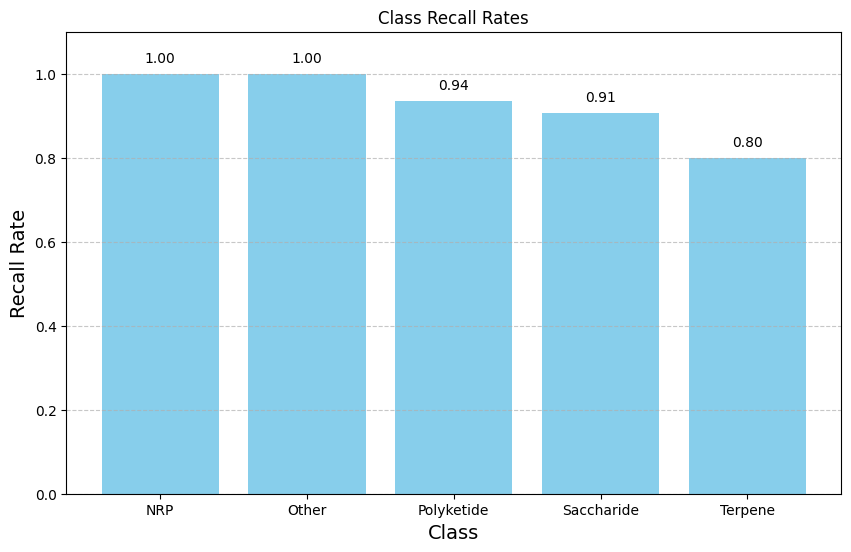

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# 统计 true positive 和 false negative，拆分元组标签
def count_individual_labels(data):
    label_counter = Counter()
    for labels in data:
        label_counter.update(labels)  # 将元组中的每个标签视为独立标签
    return label_counter

# 统计每个独立类别的计数
true_positive_counts = count_individual_labels(tpc)
false_negative_counts = count_individual_labels(fnc)
false_positive_counts = count_individual_labels(fpc)
print(true_positive_counts)

# 计算每个类别的 recall
class_recall,class_precision = {},{}
for label in true_positive_counts.keys() | false_negative_counts.keys()|false_positive_counts.keys():  # 合并所有类别
    tp_count = true_positive_counts.get(label, 0)
    fn_count = false_negative_counts.get(label, 0)
    fp_count = false_positive_counts.get(label,0)
    print(tp_count,fn_count,fp_count)
    class_recall[label] = tp_count / (tp_count + fn_count) if (tp_count + fn_count) > 0 else 0
    class_precision[label]= tp_count/(tp_count+fp_count) if (tp_count+fp_count) > 0 else 0

# 按照 recall 值排序
class_recall = {k: v for k, v in sorted(class_recall.items(), key=lambda item: item[1], reverse=True)}
class_precision = {k: v for k, v in sorted(class_precision.items(), key=lambda item: item[1], reverse=True)}

# 提取类别和 recall 值
categories = list(class_recall.keys())
recall_values = list(class_recall.values())

# 绘制条形图
plt.figure(figsize=(10, 6))
bars = plt.bar(categories, recall_values, color='skyblue')

# 为每个条形图添加高度标注
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f'{height:.2f}', ha='center', va='bottom')

plt.title('Class Recall Rates')
plt.xlabel('Class', size=14)
plt.ylabel('Recall Rate', size=14)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 显示图形
plt.show()


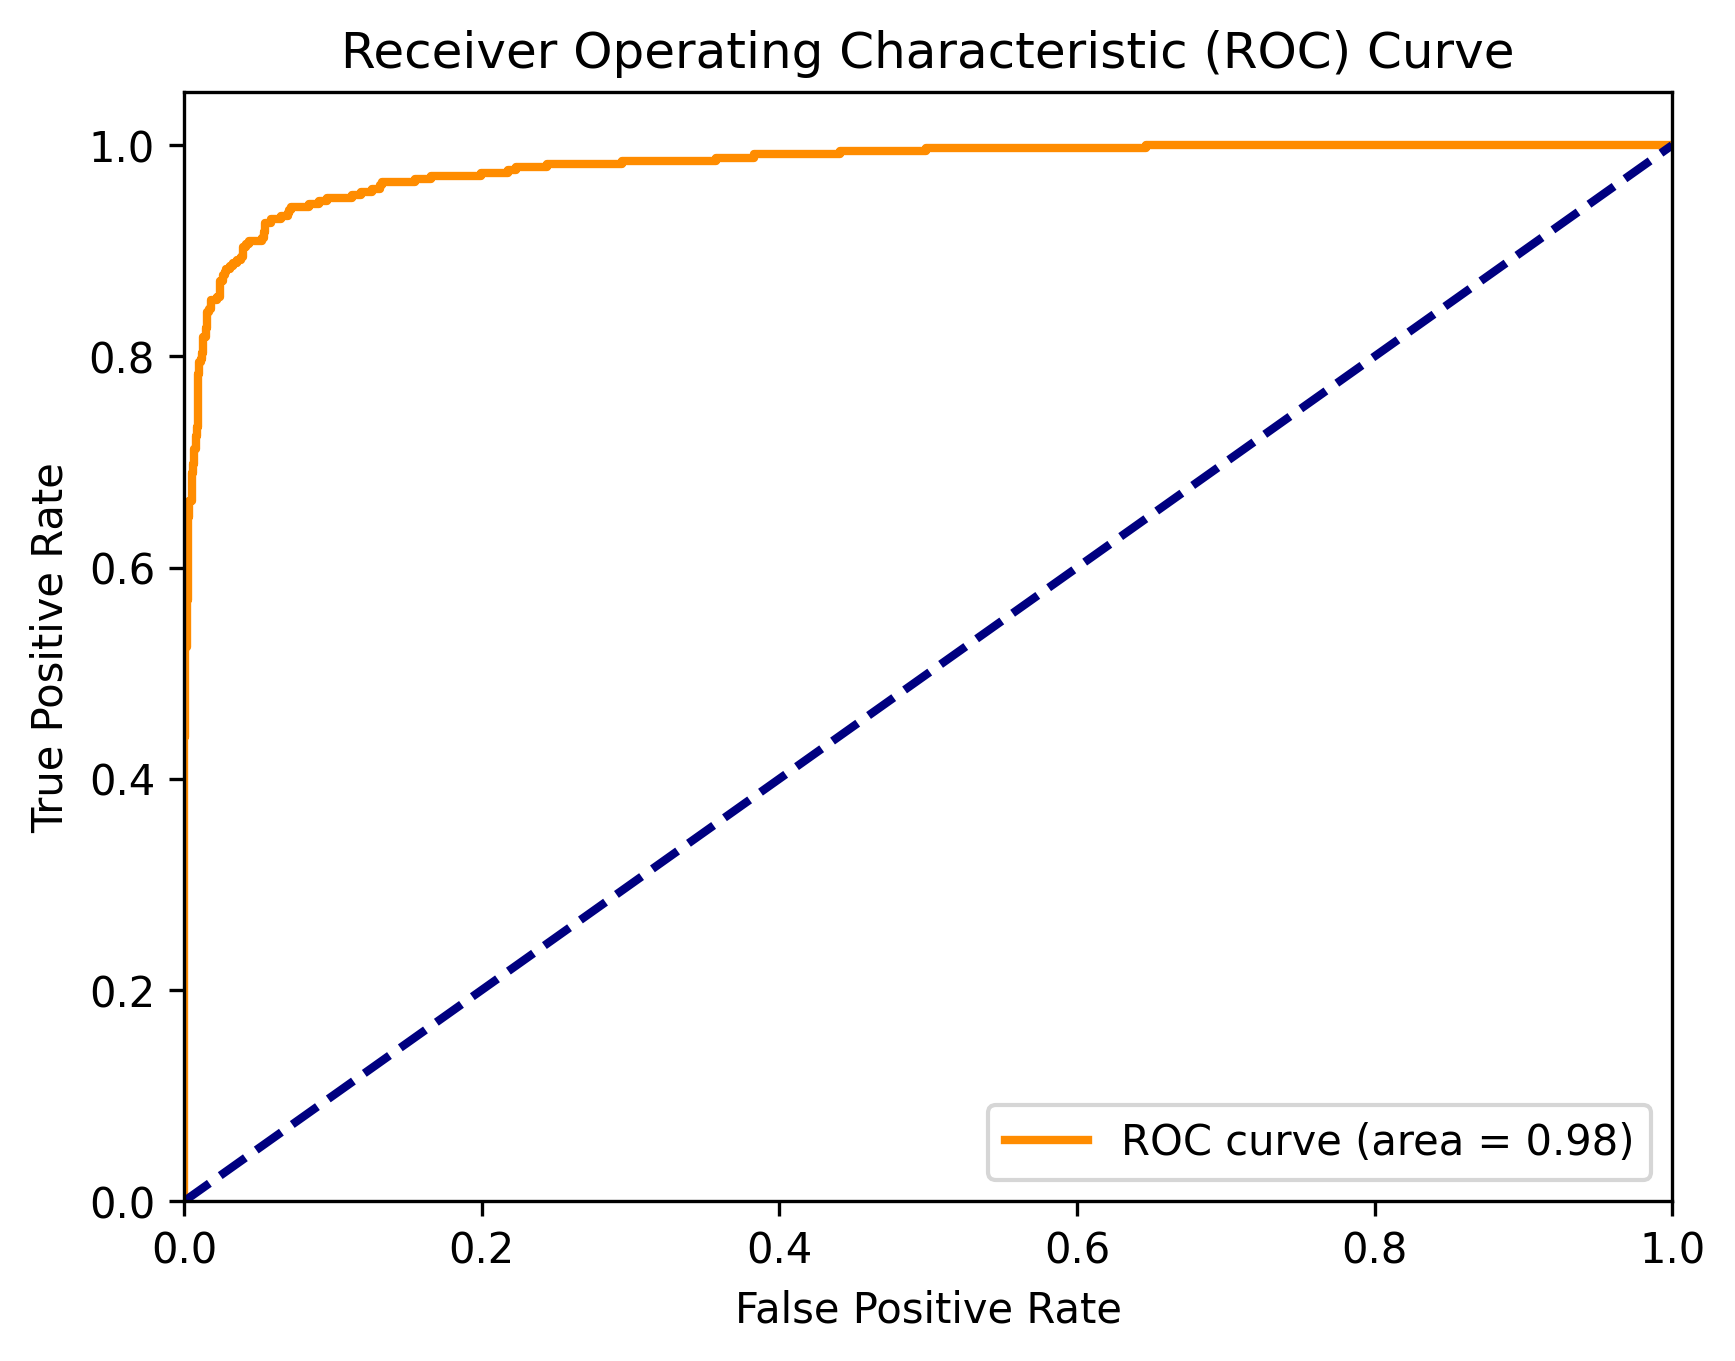

In [ ]:
    plt.rcParams['figure.dpi'] = 300
    plt.figure()
    plt.plot(best_fpr, best_tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % best_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

40
39


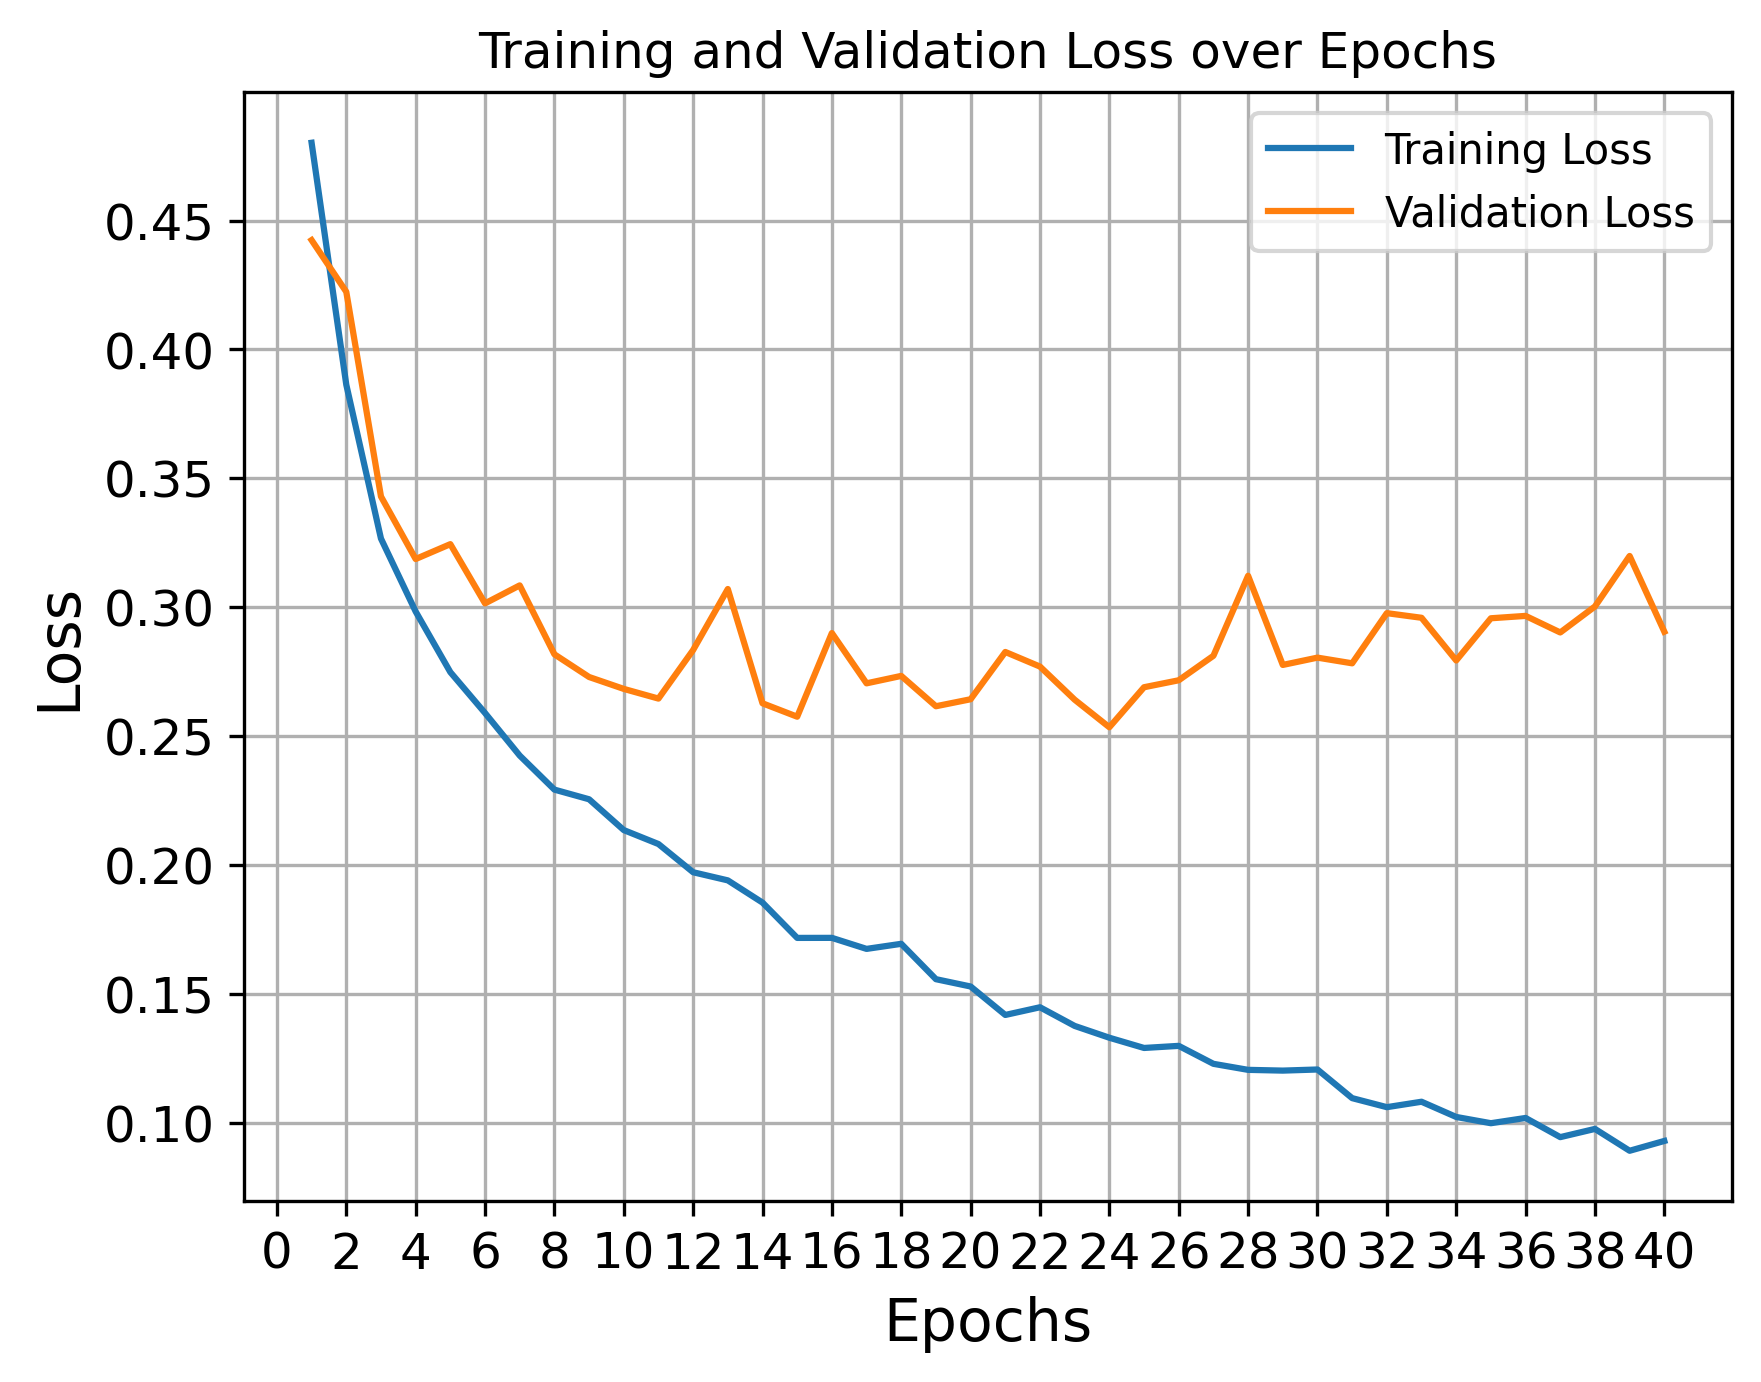

In [ ]:
print(len(avg_loss_list))
print(epoch)
epochs = list(range(1, epoch+2))
plt.figure()
plt.plot(epochs, avg_loss_list, label='Training Loss')
plt.plot(epochs, val_loss_list, label='Validation Loss')
plt.xlabel('Epochs',size=14)
plt.ylabel('Loss',size=14)
plt.xticks(size = 12)
plt.yticks(size = 12)
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.xticks(range(0,len(epochs)+1,2))
plt.show()

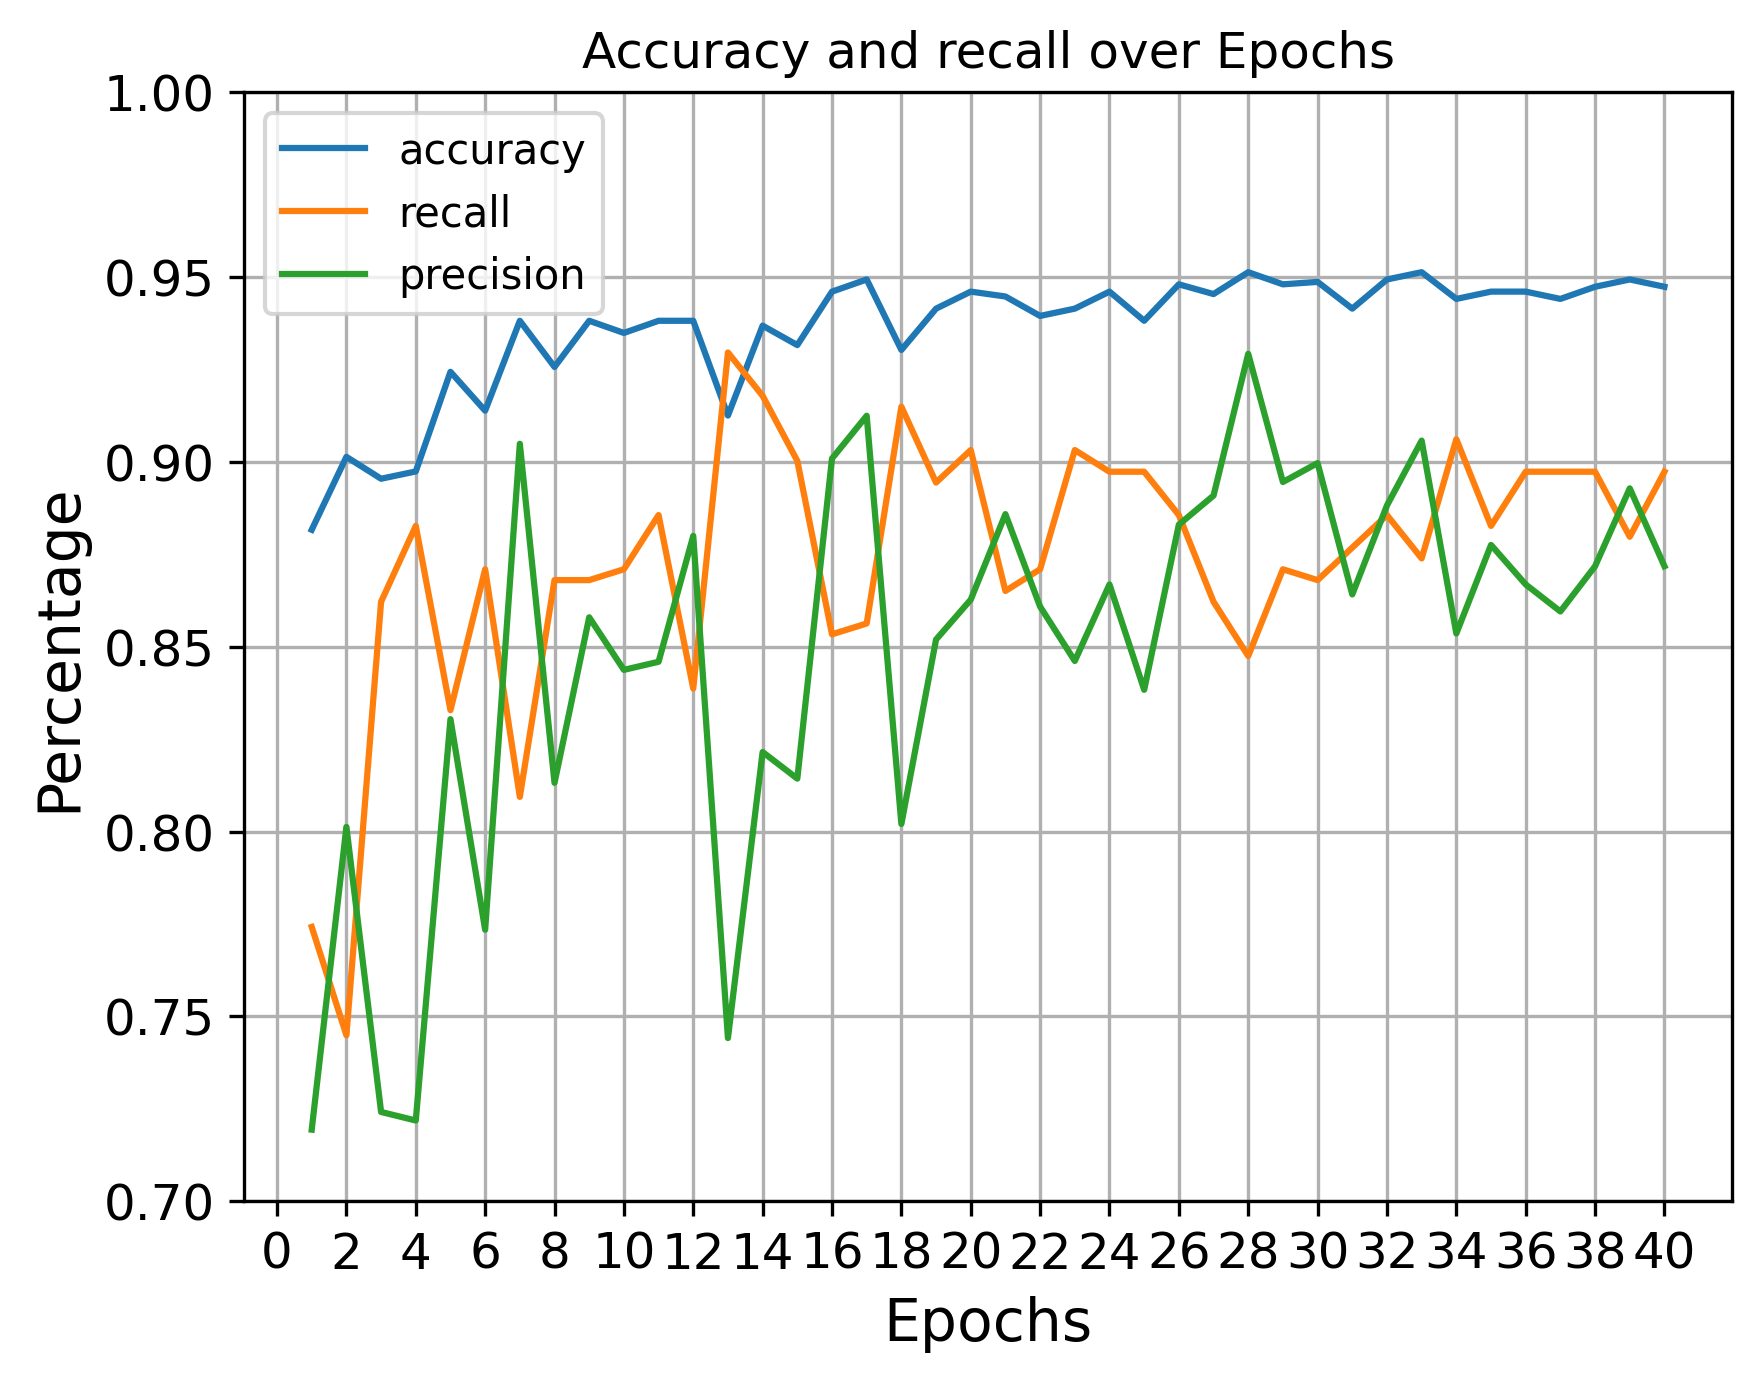

In [ ]:
epochs = list(range(1, epoch+2))
plt.figure()
plt.plot(epochs,accuracy,label='accuracy')
plt.plot(epochs, recall_list, label="recall")
plt.plot(epochs, precision_list, label="precision")
plt.xlabel('Epochs',size=14)
plt.ylabel('Percentage',size=14)
plt.xticks(size = 12)
plt.yticks(size = 12)
plt.title('Accuracy and recall over Epochs')
plt.legend()
plt.grid(True)
plt.xticks(range(0,len(epochs)+1,2))
plt.ylim(0.7,1)
plt.show()